In [2]:
print("HI")

HI


In [3]:
# install the required libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
# importing the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate ,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from scipy.stats import loguniform

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    f1_score,
)

In [ ]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42
CSV_PATH=r"A:\GitHub\Dr.-ML-multi-disease-predictor-system\datasets\diabetes.csv"
TARGET_COL="Outcome"

**2. Load Data**

In [6]:
df = pd.read_csv(CSV_PATH)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


**3. Exploratory Data Analysis**

**Target:**
- 0 - non-diabetic
- 1 - diabetic

In [7]:
# basic overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**8 Numerical columns and no categorical columns**

In [8]:
# missing values
df.isna().sum().sort_values()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
# quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Pregnancies
1    135
0    111
2    103
3     75
4     68
5     57
6     50
7     45
8     38
9     28
Name: count, dtype: int64
Glucose
100    17
99     17
125    14
111    14
106    14
129    14
102    13
105    13
95     13
112    13
Name: count, dtype: int64
BloodPressure
70    57
74    52
78    45
68    45
72    44
64    43
80    40
76    39
60    37
0     35
Name: count, dtype: int64
SkinThickness
0     227
32     31
30     27
27     23
23     22
33     20
18     20
28     20
31     19
19     18
Name: count, dtype: int64
Insulin
0      374
105     11
140      9
130      9
120      8
94       7
100      7
180      7
115      6
110      6
Name: count, dtype: int64
BMI
32.000    13
31.600    12
31.200    12
0.000     11
32.400    10
33.300    10
30.100     9
32.900     9
32.800     9
30.800     9
Name: count, dtype: int64
DiabetesPedigreeFunction
0.254    6
0.258    6
0.261    5
0.207    5
0.268    5
0.238    5
0.259    5
0.167    4
0.551    4
0.263    4
Name: count, dtype: int64
Age

>**Inference:** Some columns have missing values encoded as missing values

In [10]:
# identify columns with zero values
zero_summary = (
    df.eq(0)
      .sum()
      .to_frame(name="zero_count")
      .assign(zero_percentage=lambda x: (x["zero_count"] / len(df)) * 100)
)

zero_summary

,zero_count,zero_percentage
Pregnancies,111,14.453
Glucose,5,0.651
BloodPressure,35,4.557
SkinThickness,227,29.557
Insulin,374,48.698
BMI,11,1.432
DiabetesPedigreeFunction,0,0.000
Age,0,0.000
Outcome,500,65.104


>**NOTE:** In this dataset, Pregnancies can legitimately have a value of 0, while 0 in Glucose, BloodPressure, SkinThickness, Insulin, and BMI is physiologically invalid and therefore represents missing data. These values need to be imputed with mean/median value

In [11]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


In [12]:
# target distribution
print(df[TARGET_COL].value_counts())
print("-"*50)
print(df[TARGET_COL].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64
--------------------------------------------------
Outcome
0   65.104
1   34.896
Name: proportion, dtype: float64


>NOTE: There is some imbalance, so we will pay attention to recall/F1 and use class weighting.

In [13]:
# imbalance ratio
n_diab = (df[TARGET_COL] == 1).sum()
n_non_diab = (df[TARGET_COL] == 0).sum()
print("\nImbalance ratio (Non-diabetic : Daibetic) =", round(n_non_diab / max(n_diab, 1), 2))


Imbalance ratio (Non-diabetic : Daibetic) = 1.87


In [14]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241,0.349
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760,0.477
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000,0.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000,0.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


**Data Visualization**

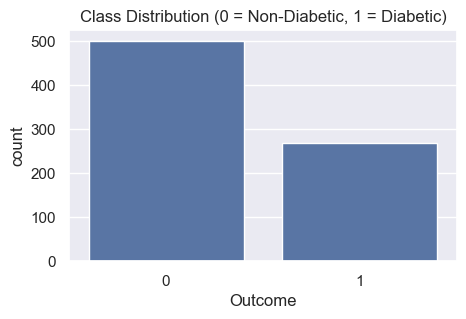

In [15]:
# visualize class imbalance
plt.figure(figsize=(5, 3))
sns.countplot(x=TARGET_COL, data=df)
plt.title("Class Distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.show()

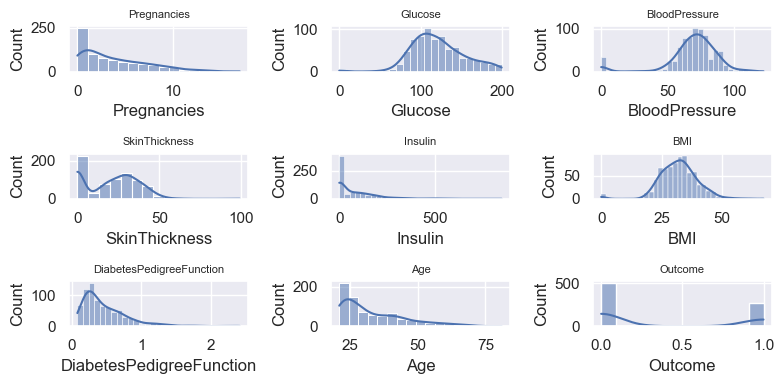

In [16]:
# histogram plot - distribution
fig, axes = plt.subplots(3, 3, figsize=(8, 4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

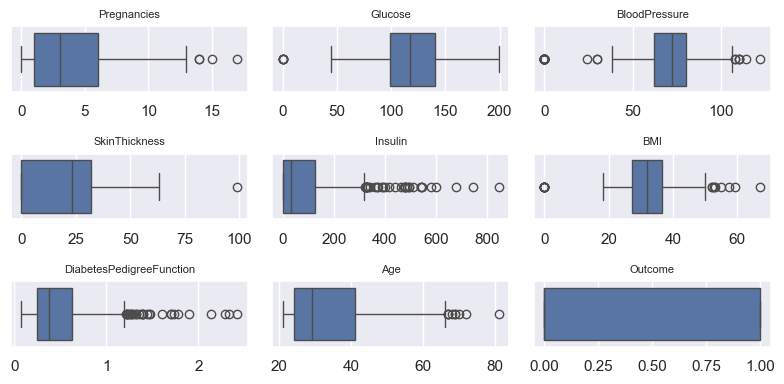

In [17]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 3, figsize=(8, 4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

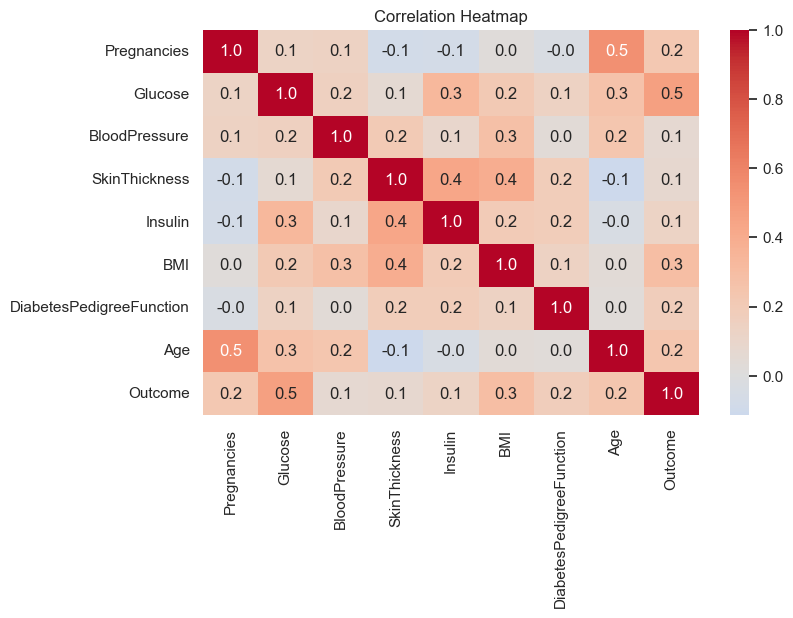

In [18]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".1f",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

**Not high correlation**

**4. Data Preprocessing**

In [19]:
X=df.drop(columns=TARGET_COL)
y=df[TARGET_COL]

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=RANDOM_STATE,stratify=y)

In [21]:
print("Dataset size", X.shape)
print("Train Dataset size", X_train.shape)
print("Test Dataset size", X_test.shape)

Dataset size (768, 8)
Train Dataset size (614, 8)
Test Dataset size (154, 8)


**Preprocess Pipeline**

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000,3.845,3.370,0.000,1.000,3.000,6.000,17.000
Glucose,768.000,120.895,31.973,0.000,99.000,117.000,140.250,199.000
BloodPressure,768.000,69.105,19.356,0.000,62.000,72.000,80.000,122.000
SkinThickness,768.000,20.536,15.952,0.000,0.000,23.000,32.000,99.000
Insulin,768.000,79.799,115.244,0.000,0.000,30.500,127.250,846.000
BMI,768.000,31.993,7.884,0.000,27.300,32.000,36.600,67.100
DiabetesPedigreeFunction,768.000,0.472,0.331,0.078,0.244,0.372,0.626,2.420
Age,768.000,33.241,11.760,21.000,24.000,29.000,41.000,81.000
Outcome,768.000,0.349,0.477,0.000,0.000,0.000,1.000,1.000


In [23]:
print("df.id: ",id(df))
print("X_train.id:",id(X_train))
X_train=X_train.copy()
print("X_train.copy:",id(X_train))

df.id:  2233573616544
X_train.id: 2234711530912
X_train.copy: 2234711534048


In [ ]:
zero_as_missing_cols=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

numerical_features=X_train.select_dtypes(include=np.number).columns.to_list()

def replace_zero_with_nan(df):
    df=df.copy() 
    for col in zero_as_missing_cols:
        if col in df.columns:
            df[col]=df[col].replace(0,np.nan)
    return df

numerical_transformer=Pipeline(steps=[
    ("zero_to_nan", FunctionTransformer(replace_zero_with_nan)),
    ("Imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())    
])

preprocess=ColumnTransformer(transformers=[
    ("num_transformer",numerical_transformer,numerical_features)
])
   

In [25]:
baseline_lr=Pipeline(steps=[
    ("preprocess",preprocess),
    ("Model",LogisticRegression())
])

In [26]:
baseline_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transformer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [27]:
# reusable evaluation function
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name):
    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc = accuracy_score(y_train, y_train_pred) * 100
    test_acc = accuracy_score(y_test, y_test_pred) * 100

    # results
    print(f"{model_name} - Train Accuracy: {train_acc:.2f}%")
    print(f"{model_name} - Test Accuracy: {test_acc:.2f}%\n")

    print("-"*40)

    print("Train Classification Report")
    print(classification_report(y_train, y_train_pred))

    print("-"*40)

    print("Test Classification Report")
    print(classification_report(y_test, y_test_pred))

In [28]:
evaluate_classifier(
    model=baseline_lr,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Baseline Logistic Regression"
)

Baseline Logistic Regression - Train Accuracy: 79.64%
Baseline Logistic Regression - Test Accuracy: 70.78%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       400
           1       0.77      0.59      0.67       214

    accuracy                           0.80       614
   macro avg       0.79      0.75      0.76       614
weighted avg       0.79      0.80      0.79       614

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



### Model Selection

In [31]:
neg=(y_train==0).sum()
pos=(y_train==1).sum()
scale_pos_weight= neg / max(pos,1)

print("scale_pos_weight:",scale_pos_weight)

scale_pos_weight: 1.8691588785046729


In [32]:
model_pipelines={
    "LogisticRegression":Pipeline(steps=[
        ("preprocess",preprocess),
        ("model",LogisticRegression(random_state=RANDOM_STATE,class_weight='balanced',max_iter=1000))
    ]),
    "SVC":Pipeline(steps=[
        ("preprocess",preprocess),
        ("model",SVC(random_state=RANDOM_STATE,class_weight='balanced'))
    ]),
    "RandomForest":Pipeline(steps=[
        ("preprocess",preprocess),
        ("model",RandomForestClassifier(random_state=RANDOM_STATE,class_weight='balanced_subsample'))
    ]),
    "XGBClassifier":Pipeline(steps=[
        ("preprocess",preprocess),
        ("model",XGBClassifier(scale_pos_weight=scale_pos_weight))
    ])
}

In [34]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

In [38]:
scores=cross_validate(
    estimator=baseline_lr,
    X=X_train,
    y=y_train,
    scoring='recall',
    cv=cv,
    return_train_score=True
)
scores

{'fit_time': array([0.01345515, 0.01134109, 0.01062369, 0.01028538, 0.0101645 ]),
 'score_time': array([0.00988317, 0.00631046, 0.00637174, 0.00675821, 0.00693417]),
 'test_score': array([0.53488372, 0.60465116, 0.58139535, 0.58139535, 0.57142857]),
 'train_score': array([0.59064327, 0.60818713, 0.58479532, 0.60818713, 0.60465116])}

In [41]:
models_performance=[]

for name, model in model_pipelines.items():
    scores=cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        scoring='recall',
        cv=cv,
        return_train_score=True
    )
    dictionary={
        'model':name,
        'cv_recall':scores['test_score'].mean()
    }
    models_performance.append(dictionary)

display(pd.DataFrame(models_performance))

,model,cv_recall
0,LogisticRegression,0.701
1,SVC,0.762
2,RandomForest,0.588
3,XGBClassifier,0.631


### Hyper parameter tuning

In [42]:
help(SVC())

Help on SVC in module sklearn.svm._classes object:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(
 |      *,
 |      C=1.0,
 |      kernel='rbf',
 |      degree=3,
 |      gamma='scale',
 |      coef0=0.0,
 |      shrinking=True,
 |      probability=False,
 |      tol=0.001,
 |      cache_size=200,
 |      class_weight=None,
 |      verbose=False,
 |      max_iter=-1,
 |      decision_function_shape='ovr',
 |      break_ties=False,
 |      random_state=None
 |  )
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to 

In [48]:
svc_opt = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC( class_weight="balanced",random_state=RANDOM_STATE))
])


In [49]:
parameters_grid=[
    {
        "model__kernel":["linear"],
        "model__C":[0.01, 0.1, 1, 10, 100]
    },
    {
        "model__kernel":["rbf"],
        "model__C":[0.01, 0.1, 1, 10, 100],
        "model__gamma":[0.001, 0.01, 0.1, "scale", "auto"]
    },
    {
        "model__kernel":["poly"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__gamma":[0.001, 0.01, 0.1, "scale"],
        "model__degree":[2,3,4]
    }
]

In [50]:

# grid search
grid = GridSearchCV(
    estimator=svc_opt,
    param_grid=parameters_grid,
    scoring="f1",
    cv=cv,
    verbose=True,
    return_train_score=True,
    n_jobs=-1
)


In [51]:

# performing gridsearchcv
grid.fit(X_train, y_train)


Fitting 5 folds for each of 90 candidates, totalling 450 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.01, 0.1, ...], 'model__kernel': ['linear']}, {'model__C': [0.01, 0.1, ...], 'model__gamma': [0.001, 0.01, ...], 'model__kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mor

In [53]:
print("Hyperparameter Tuning result:")
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Hyperparameter Tuning result:
Best params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best score: 0.6901634795182808


In [54]:
evaluate_classifier(
    model=grid.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="grid.best_estimator_"
)

grid.best_estimator_ - Train Accuracy: 82.25%
grid.best_estimator_ - Test Accuracy: 72.73%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       400
           1       0.70      0.85      0.77       214

    accuracy                           0.82       614
   macro avg       0.81      0.83      0.81       614
weighted avg       0.84      0.82      0.83       614

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.59      0.72      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



In [55]:

cv_results = pd.DataFrame(grid.cv_results_)

cv_results[
    [
        "params",
        "mean_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head()

,params,mean_test_score,rank_test_score
18,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.690,1
19,"{'model__C': 1, 'model__gamma': 'auto', 'model...",0.690,1
25,"{'model__C': 100, 'model__gamma': 0.001, 'mode...",0.685,3
17,"{'model__C': 1, 'model__gamma': 0.1, 'model__k...",0.683,4
4,"{'model__C': 100, 'model__kernel': 'linear'}",0.682,5


### Random

In [65]:
svc_opt = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC( class_weight="balanced",random_state=RANDOM_STATE))
])


In [67]:
param_distribution=[
    {
        "model__kernel":["linear"],
        "model__C":loguniform(0.01,10)
    },
    {
        "model__kernel":["rbf"],
        "model__C":loguniform(0.01,10),
        "model__gamma":loguniform(0.001,0.1)
    },
    {
        "model__kernel":["poly"],
        "model__C":loguniform(0.01,10),
        "model__gamma":(0.001,0.1),
        "model__degree":[2,3,4]
    }
]

In [72]:
random_search=RandomizedSearchCV(
    estimator=svc_opt,
    param_distributions=param_distribution,
    n_iter=1000,
    scoring='f1',
    random_state=RANDOM_STATE,
    return_train_score=True,
    n_jobs=-1
)

In [73]:
random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model__C': <scipy.stats....002084F4A6520>, 'model__kernel': ['linear']}, {'model__C': <scipy.stats....002084F670830>, 'model__gamma': <scipy.stats....002085EAE4490>, 'model__kernel': ['rbf']}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide `

In [74]:
print("Randomized SEARCH CV - Results:")
print("Best parameters:",random_search.best_params_)
print("Best Score:",random_search.best_score_)

Randomized SEARCH CV - Results:
Best parameters: {'model__C': np.float64(7.09960934247593), 'model__gamma': np.float64(0.06032920019762463), 'model__kernel': 'rbf'}
Best Score: 0.6850854677304465


In [82]:
evaluate_classifier(
    model=random_search.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="random_search.best_estimator_"
)

random_search.best_estimator_ - Train Accuracy: 84.04%
random_search.best_estimator_ - Test Accuracy: 75.32%

----------------------------------------
Train Classification Report
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       400
           1       0.72      0.87      0.79       214

    accuracy                           0.84       614
   macro avg       0.82      0.85      0.83       614
weighted avg       0.85      0.84      0.84       614

----------------------------------------
Test Classification Report
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



### Build a predictive function

In [83]:
def predict_diabetes(input_features):
    input_df = pd.DataFrame(
        [input_features],
        columns=X_train.columns
    )
    prediction = random_search.best_estimator_.predict(input_df)
    print("Model prediction:", prediction)
    if prediction[0] == 1:
        print("Diagnosis - Diabetic 🔴")
    else:
        print("Diagnosis - Non-Diabetic 🟢")


In [84]:
y_test[y_test==1].head()

630    1
387    1
408    1
78     1
678    1
Name: Outcome, dtype: int64

In [85]:
y_test[y_test==0].head()

44     0
672    0
700    0
81     0
389    0
Name: Outcome, dtype: int64

In [86]:
# sample unknown data point - access from test data index
test_1 = X_test.loc[630].tolist()
print(test_1)

[7.0, 114.0, 64.0, 0.0, 0.0, 27.4, 0.732, 34.0]


In [87]:
predict_diabetes(test_1)

Model prediction: [1]
Diagnosis - Diabetic 🔴


In [88]:
# sample unknown data point - access from test data index
test_2 = X_test.loc[700].tolist()
print(test_2)

[2.0, 122.0, 76.0, 27.0, 200.0, 35.9, 0.483, 26.0]


In [89]:
predict_diabetes(test_2)

Model prediction: [0]
Diagnosis - Non-Diabetic 🟢


>**Important Note:** This is a strong and realistic performance for this dataset. Even with correct preprocessing, cross-validation, and model tuning, some predictions will still be wrong. No model can achieve 100% accuracy on this problem because the dataset itself has overlapping patterns and noise, which creates a natural performance ceiling. While further improvements are possible through advanced techniques, this result is a solid and trustworthy stopping point for our current approach.


### Load hyper parameters to config folder as yaml file

In [112]:
diabetes_yaml_path=r"A:\GitHub\Dr.-ML-multi-disease-predictor-system\src\training\config\diabetes_hyperparams.yaml"

In [ ]:

cleaned_params = {
    key.replace("model__", ""): (
        value.item() if hasattr(value, "item") else value
    )
    for key, value in random_search.best_params_.items()
}
cleaned_params


{'C': 7.09960934247593, 'gamma': 0.06032920019762463, 'kernel': 'rbf'}

In [113]:

import yaml

with open(diabetes_yaml_path, "w") as f:
    yaml.dump(cleaned_params, f)